<a href="https://colab.research.google.com/github/abdullahh-sheikhh/voxelmorph/blob/dev/scripts/cell_tracking/train_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cell Deformation Estimation with VoxelMorph

2D deformable registration for PhC-C2DH-U373 cells using VoxelMorph, compared against Horn & Schunck classical optical flow baseline.

## 1. Setup

In [1]:
!git clone https://github.com/abdullahh-sheikhh/voxelmorph.git
%cd voxelmorph
!git checkout dev
!pip install -e . -q
!pip install imagecodecs -q

Cloning into 'voxelmorph'...
remote: Enumerating objects: 6178, done.
remote: Counting objects: 100% (920/920), done.
remote: Compressing objects: 100% (219/219), done.
remote: Total 6178 (delta 804), reused 751 (delta 700), pack-reused 5258 (from 3)
Receiving objects: 100% (6178/6178), 235.32 MiB | 35.35 MiB/s, done.
Resolving deltas: 100% (3614/3614), done.
/content/voxelmorph
Already on 'dev'
Your branch is up to date with 'origin/dev'.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Building editable for voxelmorph (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 65.1 MB/s eta 0:00:00


In [2]:
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


## 2. Download Dataset

In [3]:
from pathlib import Path

!mkdir -p dataset

if not Path('dataset/train/01').exists():
    print('Downloading training data...')
    !wget -q https://data.celltrackingchallenge.net/training-datasets/PhC-C2DH-U373.zip -O dataset/train.zip
    !cd dataset && unzip -q train.zip -d train_raw && mv train_raw/PhC-C2DH-U373/* train/ && rm -rf train_raw train.zip
else:
    print('Training data already exists')

!echo "Train sequences:" && ls dataset/train/01/ | head -3 && echo "... (115 frames total)"

Training data already exists
Train sequences:
t000.tif
t001.tif
t002.tif
... (115 frames total)


## 3. Dataset Overview

What we are working with and what we are trying to do.

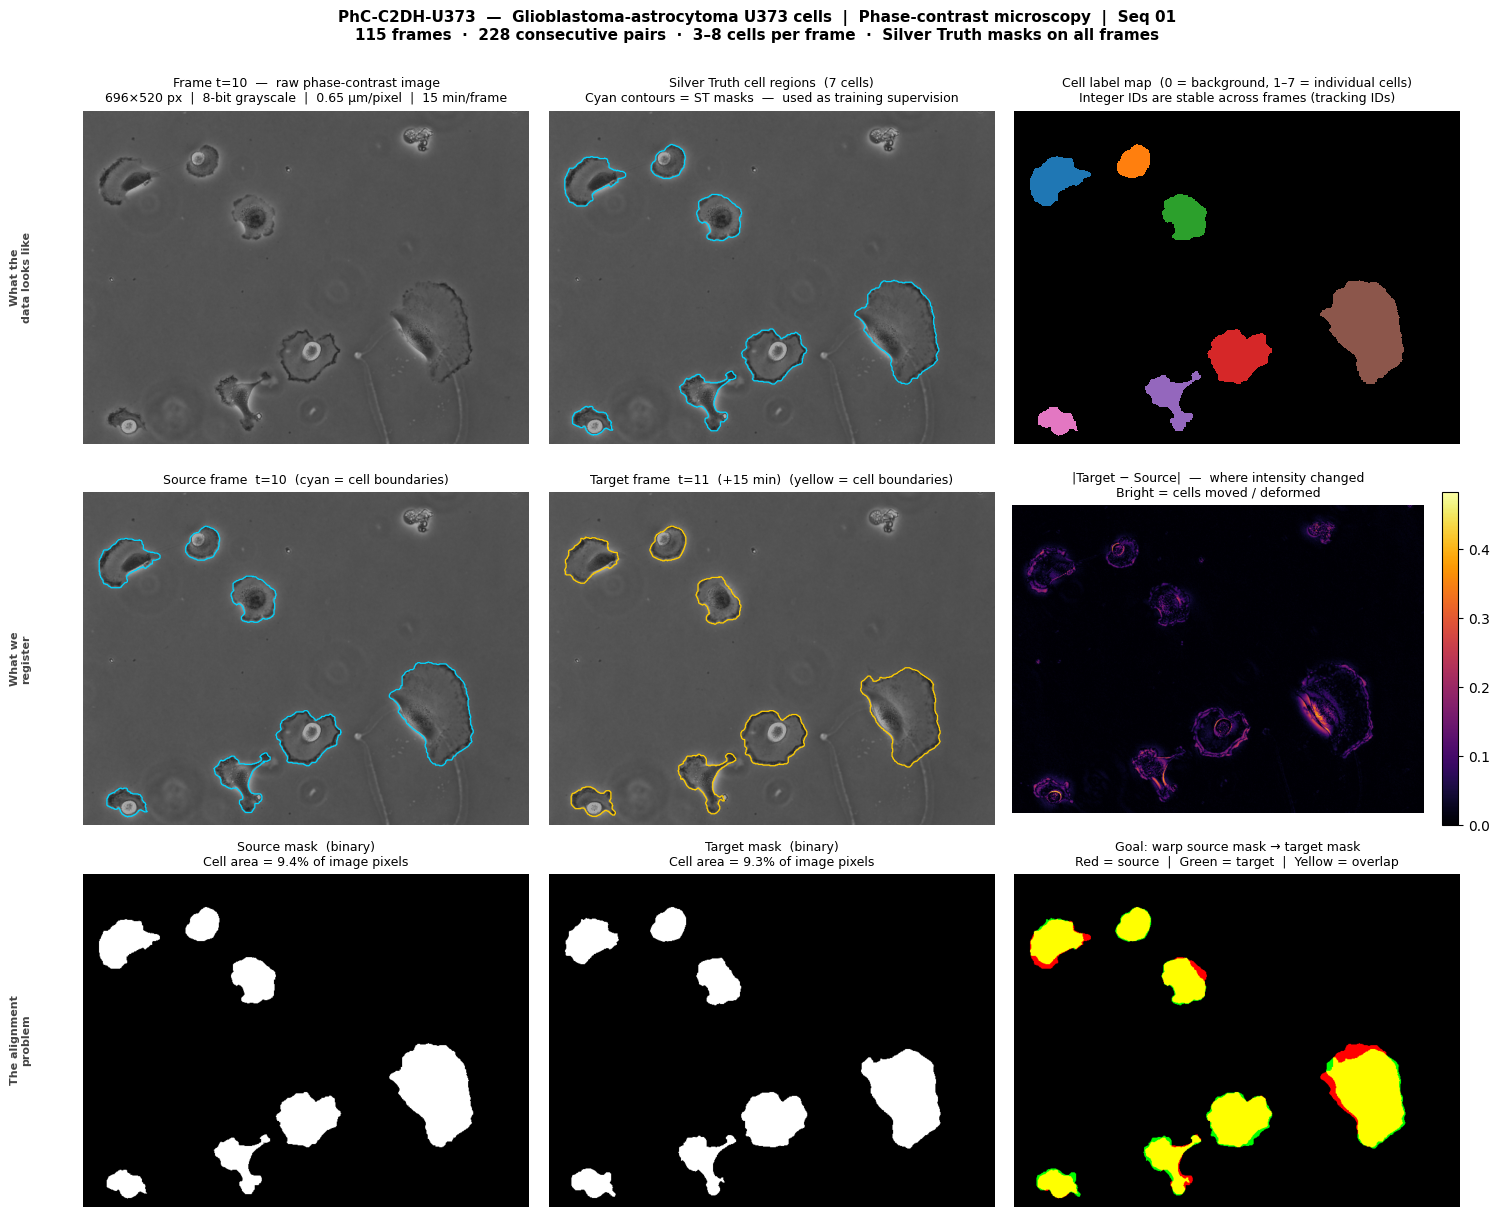

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from skimage import io
from pathlib import Path

#  Load two consecutive frames and their Silver Truth masks ─
frame_i, frame_j = 10, 11
seq_dir = Path('dataset/train/01')
st_dir  = Path('dataset/train/01_ST/SEG')

img_i  = io.imread(str(seq_dir / f't{frame_i:03d}.tif')).astype(np.float32) / 255.0
img_j  = io.imread(str(seq_dir / f't{frame_j:03d}.tif')).astype(np.float32) / 255.0
diff   = np.abs(img_j - img_i)

mask_i = io.imread(str(st_dir / f'man_seg{frame_i:03d}.tif')).astype(np.float32)
mask_j = io.imread(str(st_dir / f'man_seg{frame_j:03d}.tif')).astype(np.float32)

binary_i = mask_i > 0
binary_j = mask_j > 0
n_cells  = int(mask_i.max())

# Per-cell colour map: background = black, each cell = distinct colour
cell_cmap = ListedColormap(['black'] + [cm.tab10(i % 10) for i in range(n_cells)])

# Alignment overlay: red = source cells, green = target cells, yellow = overlap
align_rgb         = np.zeros((*img_i.shape, 3), dtype=np.float32)
align_rgb[..., 0] = binary_i.astype(float)
align_rgb[..., 1] = binary_j.astype(float)

#  Figure: 3 rows × 3 panels ─
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

kw_img = dict(cmap='gray', vmin=0, vmax=1)
kw_src = dict(colors=['#00d4ff'], linewidths=0.9, levels=[0.5])   # cyan  = source
kw_tgt = dict(colors=['#ffcc00'], linewidths=0.9, levels=[0.5])   # yellow = target

#  Row 0: single frame anatomy ─
axes[0, 0].imshow(img_i, **kw_img)
axes[0, 0].set_title(
    f'Frame t={frame_i}  —  raw phase-contrast image\n'
    f'696×520 px  |  8-bit grayscale  |  0.65 μm/pixel  |  15 min/frame', fontsize=9)

axes[0, 1].imshow(img_i, **kw_img)
axes[0, 1].contour(binary_i.astype(float), **kw_src)
axes[0, 1].set_title(
    f'Silver Truth cell regions  ({n_cells} cells)\n'
    f'Cyan contours = ST masks  —  used as training supervision', fontsize=9)

axes[0, 2].imshow(mask_i, cmap=cell_cmap, vmin=0, vmax=n_cells, interpolation='nearest')
axes[0, 2].set_title(
    f'Cell label map  (0 = background, 1–{n_cells} = individual cells)\n'
    f'Integer IDs are stable across frames (tracking IDs)', fontsize=9)

#  Row 1: consecutive pair
axes[1, 0].imshow(img_i, **kw_img)
axes[1, 0].contour(binary_i.astype(float), **kw_src)
axes[1, 0].set_title(f'Source frame  t={frame_i}  (cyan = cell boundaries)', fontsize=9)

axes[1, 1].imshow(img_j, **kw_img)
axes[1, 1].contour(binary_j.astype(float), **kw_tgt)
axes[1, 1].set_title(f'Target frame  t={frame_j}  (+15 min)  (yellow = cell boundaries)', fontsize=9)

im = axes[1, 2].imshow(diff, cmap='inferno', vmin=0, vmax=diff.max())
axes[1, 2].set_title('|Target − Source|  —  where intensity changed\nBright = cells moved / deformed', fontsize=9)
fig.colorbar(im, ax=axes[1, 2], fraction=0.046, pad=0.04)

#  Row 2: the registration problem ─
axes[2, 0].imshow(binary_i.astype(float), cmap='gray', vmin=0, vmax=1)
axes[2, 0].set_title(
    f'Source mask  (binary)\n'
    f'Cell area = {binary_i.mean()*100:.1f}% of image pixels', fontsize=9)

axes[2, 1].imshow(binary_j.astype(float), cmap='gray', vmin=0, vmax=1)
axes[2, 1].set_title(
    f'Target mask  (binary)\n'
    f'Cell area = {binary_j.mean()*100:.1f}% of image pixels', fontsize=9)

axes[2, 2].imshow(align_rgb)
axes[2, 2].set_title(
    'Goal: warp source mask → target mask\n'
    'Red = source  |  Green = target  |  Yellow = overlap', fontsize=9)

#  Row labels & final formatting ─
row_labels = ['What the\ndata looks like', 'What we\nregister', 'The alignment\nproblem']
for row, label in enumerate(row_labels):
    axes[row, 0].annotate(
        label, xy=(-0.14, 0.5), xycoords='axes fraction',
        ha='center', va='center', fontsize=8, fontweight='bold',
        rotation=90, color='#444444')

for ax in axes.flat:
    ax.axis('off')

plt.suptitle(
    'PhC-C2DH-U373  —  Glioblastoma-astrocytoma U373 cells  |  Phase-contrast microscopy  |  Seq 01\n'
    '115 frames  ·  228 consecutive pairs  ·  3–8 cells per frame  ·  Silver Truth masks on all frames',
    fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Train — VM-1

Train **VM-1** (MSE loss, direct displacement) for 100 epochs.

All training runs use two mask-supervised loss terms:
- `--mask-weight 1.0` — soft Dice on Silver Truth cell masks (primary cell alignment signal)
- `--int-weight 0.1` — cell-restricted intensity loss (sub-cellular texture gradient)
- `--lambda` — displacement field smoothness regularisation

In [5]:
!python -m scripts.cell_tracking.train \
    --data-dir dataset/train \
    --epochs 100 --batch-size 4 --lr 1e-4 \
    --loss mse --lambda 0.01 --int-steps 0 \
    --mask-weight 1.0 --int-weight 0.1 \
    --output-dir output/vm1 \
    --save-every 25

Device: cuda
Dataset: 228 pairs
Model: VxmPairwise(ndim=2, features=[16, 32, 32, 32], int_steps=0), 83,544 parameters
Loss: MSE + 0.01 * SpatialGradient(L2)

Training for 100 epochs...
Loss: MSE (alpha=1.0 mask_dice, beta=0.1 intensity, lambda=0.01 smooth)

Epochs:   0% 0/100 [00:00<?, ?it/s]Epoch 1/100 — Loss: 0.097561 (mask_dice: 0.097512, similarity: 0.000493, regularization: 0.000000)
Epochs:   9% 9/100 [01:29<14:54,  9.83s/it]Epoch 10/100 — Loss: 0.085749 (mask_dice: 0.085648, similarity: 0.000436, regularization: 0.005755)
Epochs:  19% 19/100 [03:10<13:35, 10.07s/it]Epoch 20/100 — Loss: 0.069223 (mask_dice: 0.068892, similarity: 0.000421, regularization: 0.028835)
Epochs:  24% 24/100 [04:01<12:51, 10.15s/it]  Checkpoint: output/vm1/checkpoint_epoch25.pt
Epochs:  29% 29/100 [04:51<11:56, 10.09s/it]Epoch 30/100 — Loss: 0.062331 (mask_dice: 0.061694, similarity: 0.000450, regularization: 0.059185)
Epochs:  39% 39/100 [06:33<10:17, 10.12s/it]Epoch 40/100 — Loss: 0.057021 (mask_dice: 

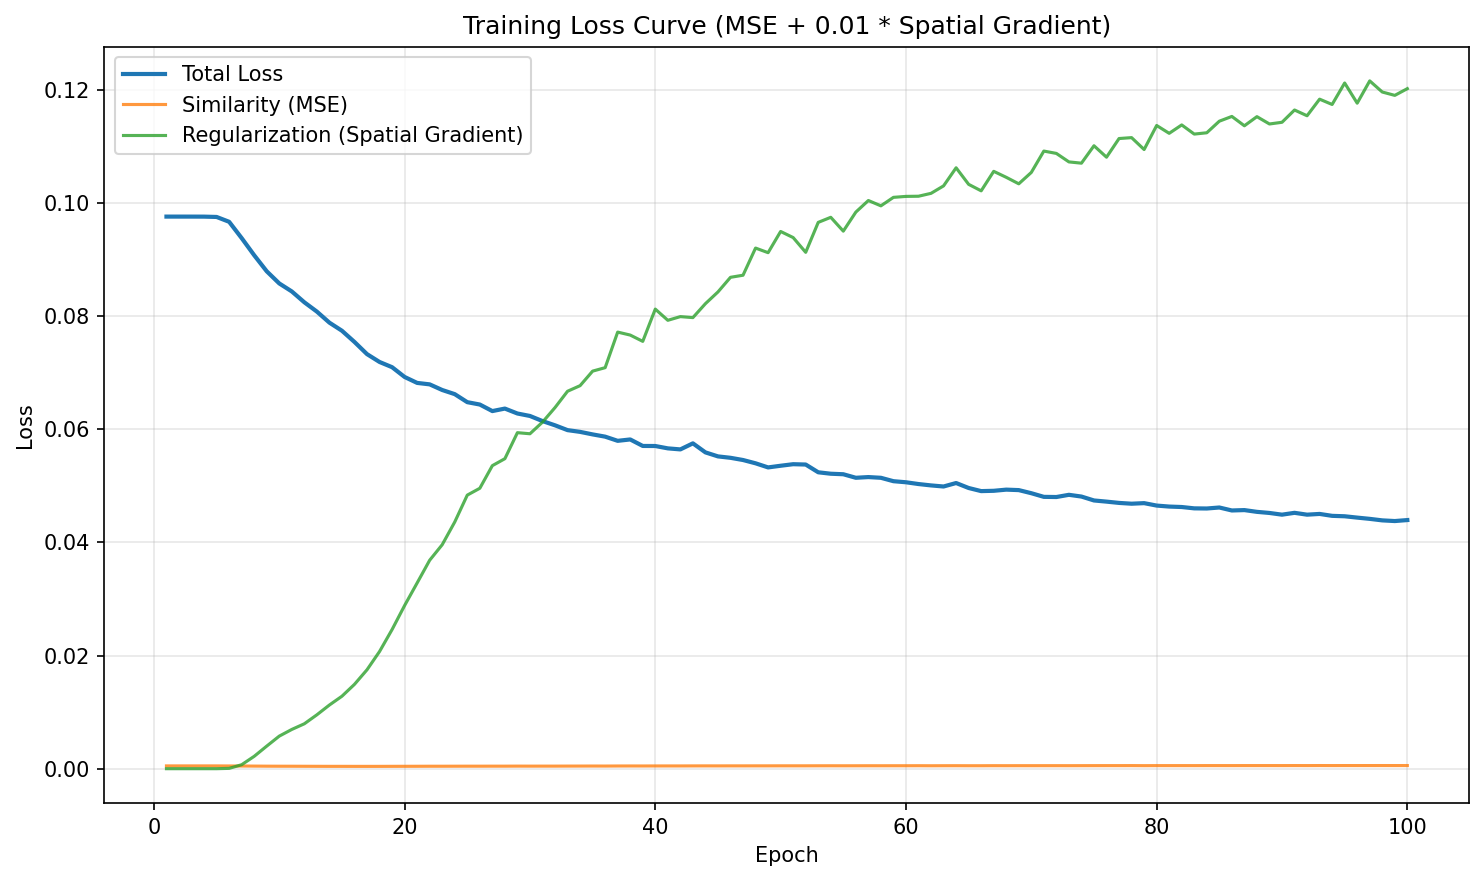

In [6]:
from IPython.display import Image, display
display(Image(filename='output/vm1/loss_curve.png', width=800))

## 5. Evaluate — VM-1

Compute Dice score (primary), Jacobian determinant, per-cell deformation statistics, and runtime. Includes the Horn & Schunck baseline.

In [7]:
!python -m scripts.cell_tracking.evaluate \
    --model output/vm1/best.pt \
    --data-dir dataset/train \
    --gt-dir dataset/train \
    --output-dir output/eval_vm1 \
    --max-pairs 0

Device: cuda
Pairs: 228, Baselines: True

Evaluating 228 pairs...

  Pair 0: Dice=0.8561, MaskedMSE=0.005911
  Pair 1: Dice=0.8716, MaskedMSE=0.004568
  Pair 2: Dice=0.8178, MaskedMSE=0.006640
  Pair 3: Dice=0.8599, MaskedMSE=0.006161
  Pair 4: Dice=0.8838, MaskedMSE=0.006344
  Pair 5: Dice=0.8722, MaskedMSE=0.006626
  Pair 6: Dice=0.8656, MaskedMSE=0.007553
  Pair 7: Dice=0.8808, MaskedMSE=0.004610
  Pair 8: Dice=0.7643, MaskedMSE=0.004838
  Pair 9: Dice=0.8588, MaskedMSE=0.005738
  Pair 10: Dice=0.8656, MaskedMSE=0.005150
  Pair 11: Dice=0.8511, MaskedMSE=0.005100
  Pair 12: Dice=0.8696, MaskedMSE=0.005934
  Pair 13: Dice=0.8650, MaskedMSE=0.005674
  Pair 14: Dice=0.8745, MaskedMSE=0.005557
  Pair 15: Dice=0.8811, MaskedMSE=0.005632
  Pair 16: Dice=0.8548, MaskedMSE=0.006450
  Pair 17: Dice=0.8722, MaskedMSE=0.006630
  Pair 18: Dice=0.8780, MaskedMSE=0.006420
  Pair 19: Dice=0.8962, MaskedMSE=0.005621
  Pair 20: Dice=0.8504, MaskedMSE=0.008051
  Pair 21: Dice=0.8828, MaskedMSE=0.0092


pair_0000.png


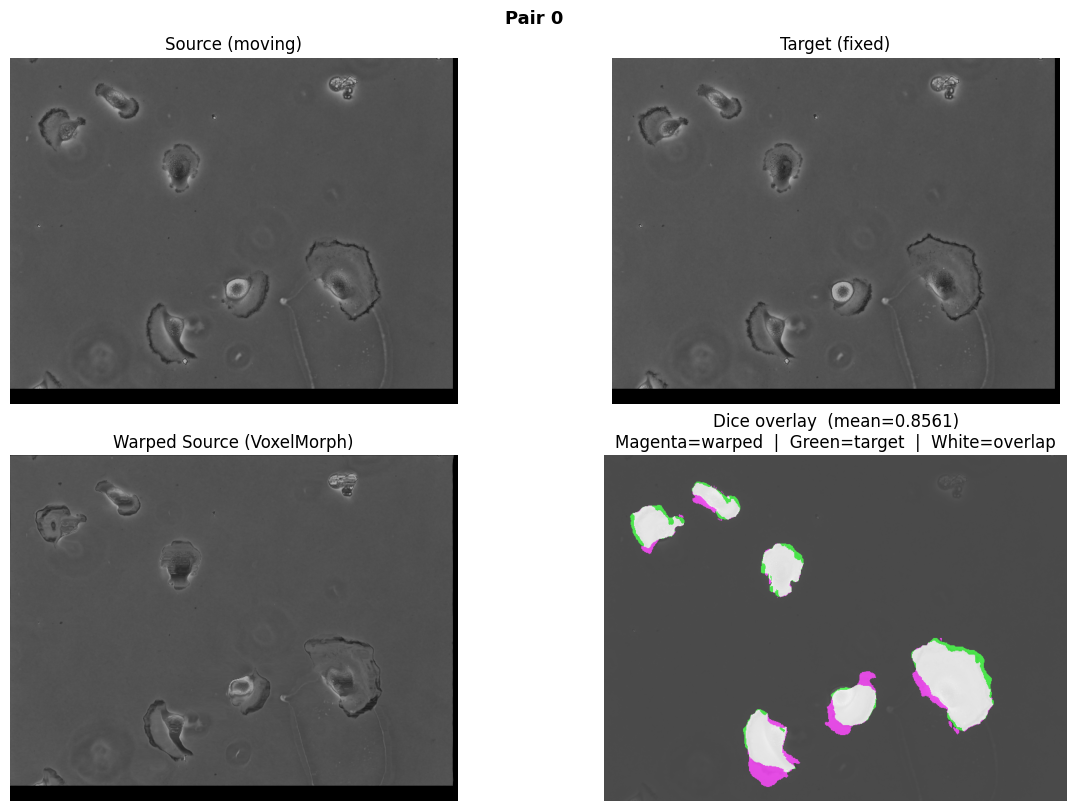


pair_0001.png


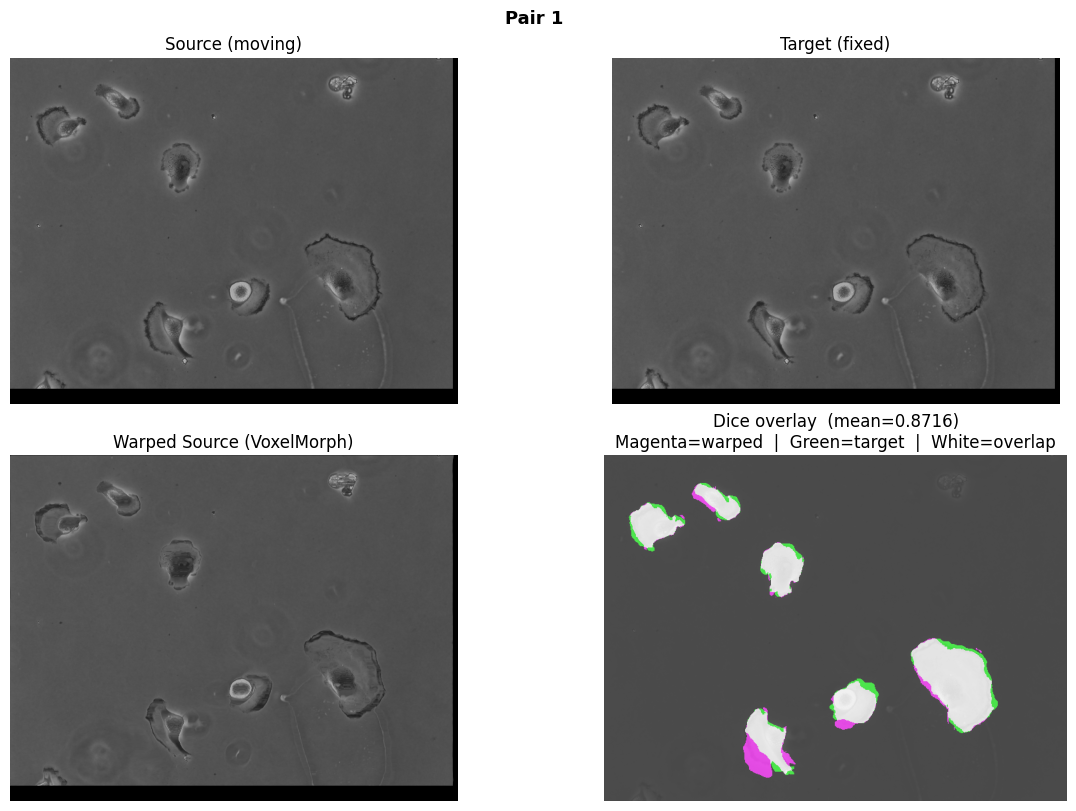


pair_0002.png


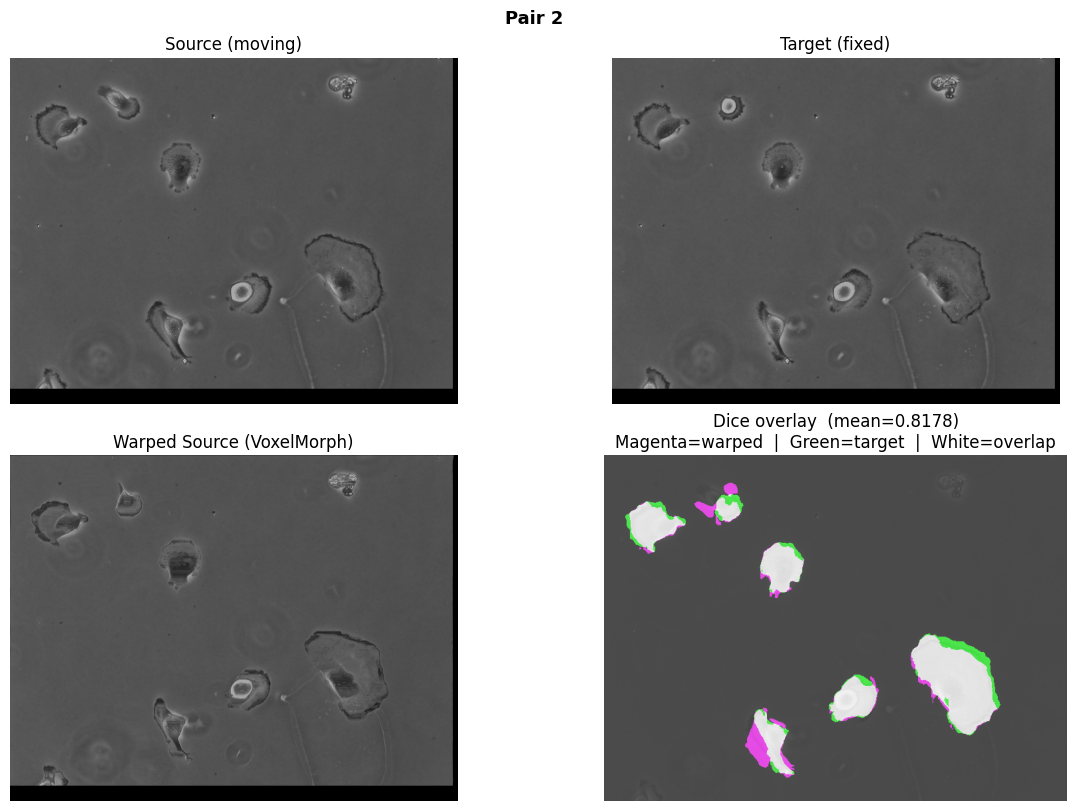


pair_0003.png


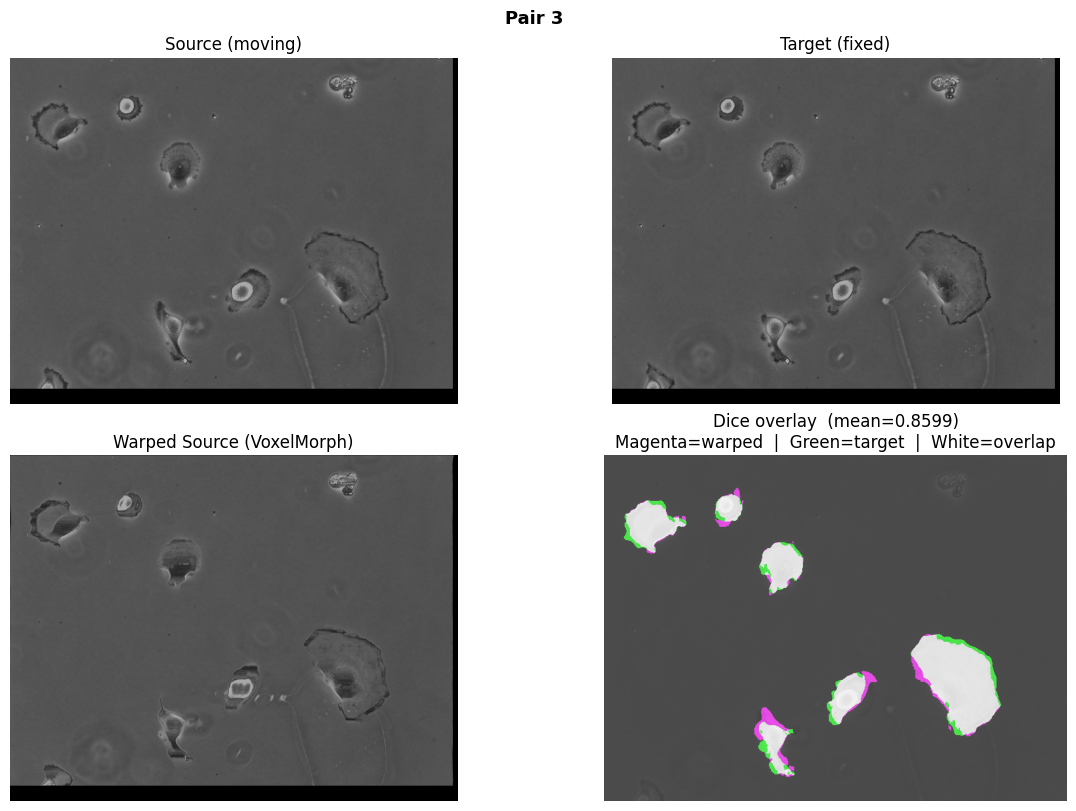


pair_0004.png


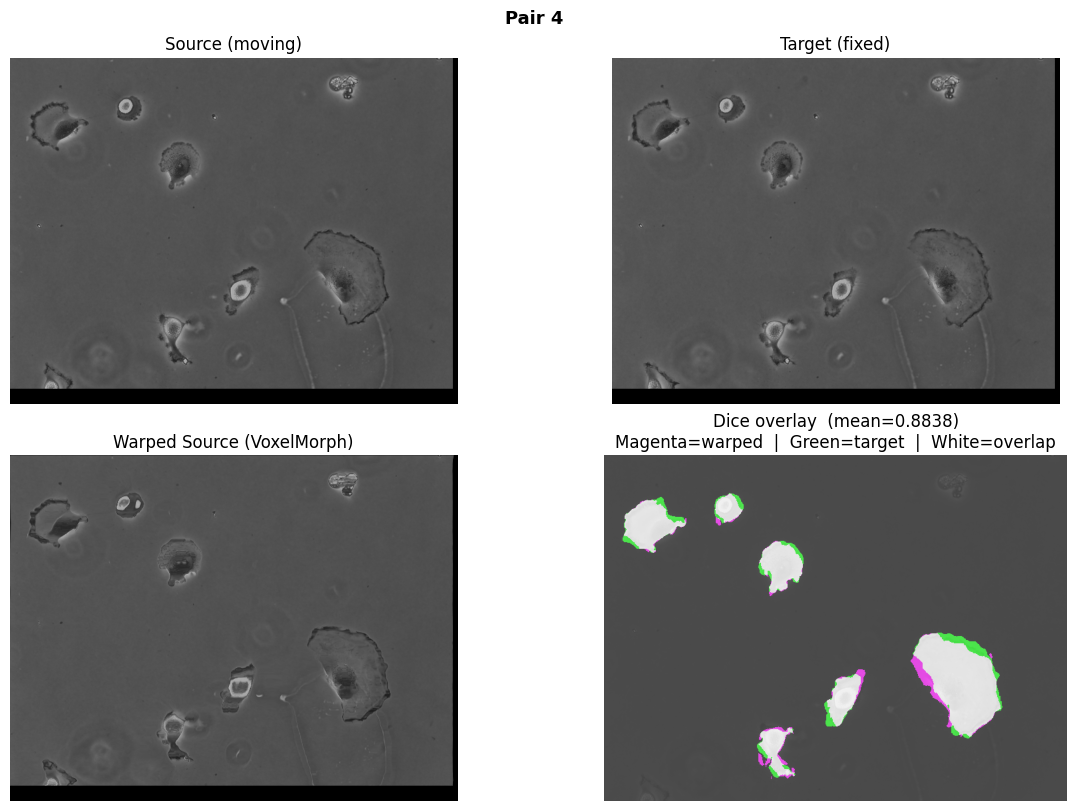

In [8]:
from IPython.display import Image, display
from pathlib import Path

for img_path in sorted(Path('output/eval_vm1').glob('pair_*.png'))[:5]:
    print(f'\n{img_path.name}')
    display(Image(filename=str(img_path), width=900))

## 6. Variant Experiments

Train VM-2 (NCC, direct), VM-3 (MSE, diffeomorphic), VM-4 (NCC, diffeomorphic), then evaluate all four variants for the comparison table.

In [9]:
# VM-2: NCC loss, direct displacement
!python -m scripts.cell_tracking.train \
    --data-dir dataset/train \
    --epochs 100 --batch-size 4 --lr 1e-4 \
    --loss ncc --lambda 1.0 --int-steps 0 \
    --mask-weight 1.0 --int-weight 0.1 \
    --output-dir output/vm2 \
    --save-every 25

Device: cuda
Dataset: 228 pairs
Model: VxmPairwise(ndim=2, features=[16, 32, 32, 32], int_steps=0), 83,544 parameters
Loss: NCC + 1.0 * SpatialGradient(L2)

Training for 100 epochs...
Loss: NCC (alpha=1.0 mask_dice, beta=0.1 intensity, lambda=1.0 smooth)

Epochs:   0% 0/100 [00:00<?, ?it/s]Epoch 1/100 — Loss: 0.088549 (mask_dice: 0.097512, similarity: -0.089624, regularization: 0.000000)
Epochs:   9% 9/100 [01:42<16:50, 11.10s/it]Epoch 10/100 — Loss: 0.081215 (mask_dice: 0.088692, similarity: -0.091011, regularization: 0.001624)
Epochs:  19% 19/100 [03:35<15:20, 11.36s/it]Epoch 20/100 — Loss: 0.065981 (mask_dice: 0.072209, similarity: -0.093691, regularization: 0.003141)
Epochs:  24% 24/100 [04:32<14:35, 11.52s/it]  Checkpoint: output/vm2/checkpoint_epoch25.pt
Epochs:  29% 29/100 [05:29<13:30, 11.41s/it]Epoch 30/100 — Loss: 0.059917 (mask_dice: 0.065300, similarity: -0.095076, regularization: 0.004125)
Epochs:  39% 39/100 [07:22<11:35, 11.40s/it]Epoch 40/100 — Loss: 0.056008 (mask_dice

In [10]:
# VM-3: MSE loss, diffeomorphic (integration steps = 7)
!python -m scripts.cell_tracking.train \
    --data-dir dataset/train \
    --epochs 100 --batch-size 4 --lr 1e-4 \
    --loss mse --lambda 0.01 --int-steps 7 \
    --mask-weight 1.0 --int-weight 0.1 \
    --output-dir output/vm3 \
    --save-every 25

Device: cuda
Dataset: 228 pairs
Model: VxmPairwise(ndim=2, features=[16, 32, 32, 32], int_steps=7), 83,544 parameters
Loss: MSE + 0.01 * SpatialGradient(L2)

Training for 100 epochs...
Loss: MSE (alpha=1.0 mask_dice, beta=0.1 intensity, lambda=0.01 smooth)

Epochs:   0% 0/100 [00:00<?, ?it/s]Epoch 1/100 — Loss: 0.097561 (mask_dice: 0.097511, similarity: 0.000493, regularization: 0.000000)
Epochs:   9% 9/100 [01:49<18:23, 12.13s/it]Epoch 10/100 — Loss: 0.088852 (mask_dice: 0.088734, similarity: 0.000492, regularization: 0.006837)
Epochs:  19% 19/100 [03:49<16:17, 12.07s/it]Epoch 20/100 — Loss: 0.065698 (mask_dice: 0.065185, similarity: 0.000429, regularization: 0.046961)
Epochs:  24% 24/100 [04:50<15:19, 12.09s/it]  Checkpoint: output/vm3/checkpoint_epoch25.pt
Epochs:  29% 29/100 [05:50<14:09, 11.96s/it]Epoch 30/100 — Loss: 0.057352 (mask_dice: 0.056137, similarity: 0.000460, regularization: 0.116849)
Epochs:  39% 39/100 [07:48<12:03, 11.86s/it]Epoch 40/100 — Loss: 0.051030 (mask_dice: 

In [ ]:
# VM-4: NCC loss, diffeomorphic (integration steps = 7)
!python -m scripts.cell_tracking.train \
    --data-dir dataset/train \
    --epochs 100 --batch-size 4 --lr 1e-4 \
    --loss ncc --lambda 1.0 --int-steps 7 \
    --mask-weight 1.0 --int-weight 0.1 \
    --output-dir output/vm4 \
    --save-every 25

Device: cuda
Dataset: 228 pairs
Model: VxmPairwise(ndim=2, features=[16, 32, 32, 32], int_steps=7), 83,544 parameters
Loss: NCC + 1.0 * SpatialGradient(L2)

Training for 100 epochs...
Loss: NCC (alpha=1.0 mask_dice, beta=0.1 intensity, lambda=1.0 smooth)

Epochs:   0% 0/100 [00:00<?, ?it/s]Epoch 1/100 — Loss: 0.088550 (mask_dice: 0.097512, similarity: -0.089624, regularization: 0.000000)
Epochs:   1% 1/100 [00:12<21:24, 12.97s/it]

In [ ]:
from IPython.display import Image, display
from pathlib import Path

for name, d in [('VM-1 (MSE, direct)',        'output/vm1'),
                ('VM-2 (NCC, direct)',        'output/vm2'),
                ('VM-3 (MSE, diffeomorphic)', 'output/vm3'),
                ('VM-4 (NCC, diffeomorphic)', 'output/vm4')]:
    p = Path(d) / 'loss_curve.png'
    if p.exists():
        print(f'\n{name}')
        display(Image(filename=str(p), width=700))

In [ ]:
from pathlib import Path

variants = {
    'VM-1 (MSE, direct)':        ('output/vm1/best.pt', 0, 'output/eval_vm1'),
    'VM-2 (NCC, direct)':        ('output/vm2/best.pt', 0, 'output/eval_vm2'),
    'VM-3 (MSE, diffeomorphic)': ('output/vm3/best.pt', 7, 'output/eval_vm3'),
    'VM-4 (NCC, diffeomorphic)': ('output/vm4/best.pt', 7, 'output/eval_vm4'),
}

for name, (model_path, int_steps, eval_dir) in variants.items():
    if not Path(model_path).exists():
        print(f'Skipping {name}: {model_path} not found')
        continue
    print(f'\nEvaluating {name}...')
    !python -m scripts.cell_tracking.evaluate \
        --model {model_path} \
        --data-dir dataset/train \
        --gt-dir dataset/train \
        --int-steps {int_steps} \
        --output-dir {eval_dir} \
        --no-baselines \
        --max-pairs 0

In [ ]:
import json
import pandas as pd
from pathlib import Path

def load(path, key):
    p = Path(path)
    return json.loads(p.read_text()).get(key) if p.exists() else None

def fmt(m):
    return {
        'Dice':        f"{m['dice_mean']:.4f} ± {m['dice_std']:.4f}" if 'dice_mean' in m else '—',
        'Masked MSE':  f"{m['masked_mse_mean']:.6f} ± {m['masked_mse_std']:.6f}" if 'masked_mse_mean' in m else '—',
        'Runtime (s)': f"{m['runtime_mean']:.4f}" if 'runtime_mean' in m else '—',
    }

rows = []

hs = load('output/eval_vm1/metrics.json', 'horn_schunck')
if hs:
    rows.append({'Method': 'Horn & Schunck', **fmt(hs)})

for name, d in [('VM-1 (MSE, direct)',        'output/eval_vm1'),
                ('VM-2 (NCC, direct)',        'output/eval_vm2'),
                ('VM-3 (MSE, diffeomorphic)', 'output/eval_vm3'),
                ('VM-4 (NCC, diffeomorphic)', 'output/eval_vm4')]:
    m = load(f'{d}/metrics.json', 'vxm')
    if m:
        rows.append({'Method': name, **fmt(m)})

pd.DataFrame(rows).set_index('Method')

## 7. Download Results

In [ ]:
# from google.colab import files
# !zip -r results.zip output/ 2>/dev/null; true
# files.download('results.zip')